# Fine-tuning ViT (Google Pre-trained) on Higher Resolution Images

## Task: Binary Classification (Fake vs Real Faces) from Kaggle

# 1. Import and Hardware Setup

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math
import random

!pip install wandb -q
import wandb

In [62]:

print("❌ Not running on Colab, using local path")
DATA_PATH = "./data"
SAVE_PATH = "./"
os.makedirs(SAVE_PATH, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Log in to W&B (Will ask for API Key on first run)
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


❌ Not running on Colab, using local path
Using device: cuda


False

## 1. Hyperparamters

In [63]:
BATCH_SIZE = 32
EPOCHS = 1
LR = 1e-4
IMG_SIZE = 256
SEED = 42

## 2. Dataset Preparation

In [64]:
!pip install kagglehub -q
import kagglehub

os.environ["KAGGLEHUB_CACHE"] = os.path.abspath(DATA_PATH)

path = kagglehub.dataset_download("ayushmandatta1/deepdetect-2025")

print("✅ Downloaded the dataset")

train_dir = os.path.join(path, "ddata", "train")
test_dir = os.path.join(path, "ddata", "test")

print(f"train_dir: {train_dir}")
print(f"test_dir: {test_dir}")

✅ Downloaded the dataset
train_dir: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train
test_dir: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/test


In [65]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.GaussianBlur(kernel_size=5),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing() # Always keep it after ToTensor
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [66]:
from torch.utils.data import random_split
import copy

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

# 1. Load the full dataset
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

# 2. Split the training dataset
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size], generator=split_generator)

# 3. Create a shallow copy of the underlying dataset for validation
val_subset.dataset = copy.copy(full_train_dataset)

# 4. Overwrite the transform only for the validation subset
val_subset.dataset.transform = test_transform

In [67]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

train_gen = torch.Generator().manual_seed(SEED)
eval_gen = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=train_gen)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=eval_gen)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=eval_gen)

## 3. Load & Interpolate Positional Embeddings

Since the resolution changed from 224 to 256, the number of patches changed:

- **Old:** `196`
- **New:** `256`

The 14x14 positional grid need to be interpolated to 16x16

In [68]:
def load_state_dict_with_interpolation(model, state_dict):

    # 1. Get the current model's pos_embedding shape
    # (1, N+1, embed_dim) -> (1, 257, 768)
    new_pos_embed = model.encoder.pos_embedding.data
    num_patches_new = new_pos_embed.shape[1] - 1 #256

    # 2. Get loaded checkpoint's pos_embedding
    old_pos_embed = state_dict['encoder.pos_embedding'] # (1, 197, 768)

    # if shapes match, return imediately
    if old_pos_embed.shape == new_pos_embed.shape:
        print("Shapes match, no interpolation needed.")
        return state_dict

    # 3. Separate CLS token and Grid tokens
    old_cls_tokens = old_pos_embed[:, 0:1, :]
    old_grid_tokens = old_pos_embed[:, 1:, :]

    # 4. Reshape grid tokens to 2D image-like grid (B, C, H, W) for interpolation
    grid_size_old = int(math.sqrt(old_grid_tokens.shape[1]))
    embed_dim = old_grid_tokens.shape[-1]

    # Permute to (B, N, C) -> (B, C, N) -> (B, C, H, W) (1, 768, 14, 14)
    old_grid_tokens = old_grid_tokens.permute(0, 2, 1).reshape(1, embed_dim, grid_size_old, grid_size_old)

    # 5. Calculate new grid size
    grid_size_new = int(math.sqrt(num_patches_new))

    # 6. Interpolate
    new_grid_tokens = F.interpolate(
        old_grid_tokens,
        size=(grid_size_new, grid_size_new),
        mode='bicubic',
        align_corners=False
    )

    # 7. Reshape back to sequence (1, 256, 768) and permute back
    new_grid_tokens = new_grid_tokens.flatten(2).transpose(1, 2)

    # 8. Concatenate cls token back
    new_pos_embed = torch.cat((old_cls_tokens, new_grid_tokens), dim=1)

    # 9. Update state_dict
    state_dict['encoder.pos_embedding'] = new_pos_embed

    return state_dict

In [69]:
# If MacOS activate this code

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [70]:
# load standard ViT-Base-16 capable of processing IMG_SIZE
# but no loading weights yet
model = models.vit_b_16(weights=None, image_size=IMG_SIZE)

# Load standard ImageNet weights manually
pretrained_weights = models.ViT_B_16_Weights.IMAGENET1K_V1.get_state_dict(progress=True)

# Interpolate positional embeddings
pretrained_weights = load_state_dict_with_interpolation(model, pretrained_weights)

# Load the modified weights into the new model
model.load_state_dict(pretrained_weights)

# Modify Head for 2 Classes (Fake vs Real)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 2)

# Zero Initialization like in the ViT Paper
nn.init.zeros_(model.heads.head.weight)
nn.init.zeros_(model.heads.head.bias)

model = model.to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 85.85M
Using 2 GPUs


## 4. Training

In [71]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [72]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-6, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-4,                           # The absolute maximum LR it will hit during the cycle
    steps_per_epoch=len(train_loader),     # How many batches per epoch?
    epochs=EPOCHS,                         # Total epochs you plan to train
    pct_start=0.1
)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/4106090932.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [73]:
!pip install tqdm -q
from tqdm.auto import tqdm

def train(model, loader, criterion, optimizer, scheduler):
    model.train()
    train_loss, train_acc = 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        train_loss += loss.item() * x.size(0)
        train_acc += (out.argmax(1) == y).sum().item()

    return train_loss / len(loader.dataset), train_acc / len(loader.dataset)

In [74]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_acc += (out.argmax(1) == y).sum().item()

    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [75]:
def evaluate(model, loader):
    model.eval()
    eval_acc = 0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)

            eval_acc += (out.argmax(1) == y).sum().item()

    return eval_acc / len(loader.dataset)

In [76]:
wandb.init(
    project="FT-ViT-Google-pretrained",
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "architecture": "ViT-B-16"
    }
)

train_accuracies, val_accuracies = [], []
early_stopping = EarlyStopping(patience=3)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    print(f"{epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}," +
          f" train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, "module") else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
print("Loaded best model")

test_acc = evaluate(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

wandb.log({"final_test_acc": test_acc})
wandb.finish()

epoch,▁
lr,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
lr,0.0
train_acc,0.83208
train_loss,0.44556
val_acc,0.97279


Training:   0%|          | 0/2261 [00:00<?, ?it/s]

/tmp/ipykernel_55/355028760.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validation:   0%|          | 0/566 [00:00<?, ?it/s]

1/1: train_loss: 0.4456, val_loss: 0.2464, train_acc: 0.8321, val_acc: 0.9728
Loaded best model


Testing:   0%|          | 0/681 [00:00<?, ?it/s]

Final test accuracy: 0.9548


epoch,▁
final_test_acc,▁
lr,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
final_test_acc,0.95481
lr,0.0
train_acc,0.83208


In [77]:
import os

model_name = 'FT_ViT_Fake_Real_Face.pth'
save_path = os.path.join('./', model_name)

torch.save(model.state_dict(), save_path)

print(f"✅ Model saved to: {save_path}")

✅ Model saved to: ./FT_ViT_Fake_Real_Face.pth


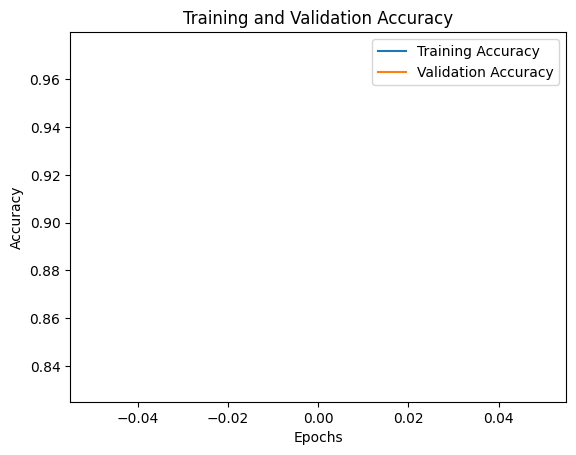

In [78]:
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

## 5. Heatmap with Grad-CAM

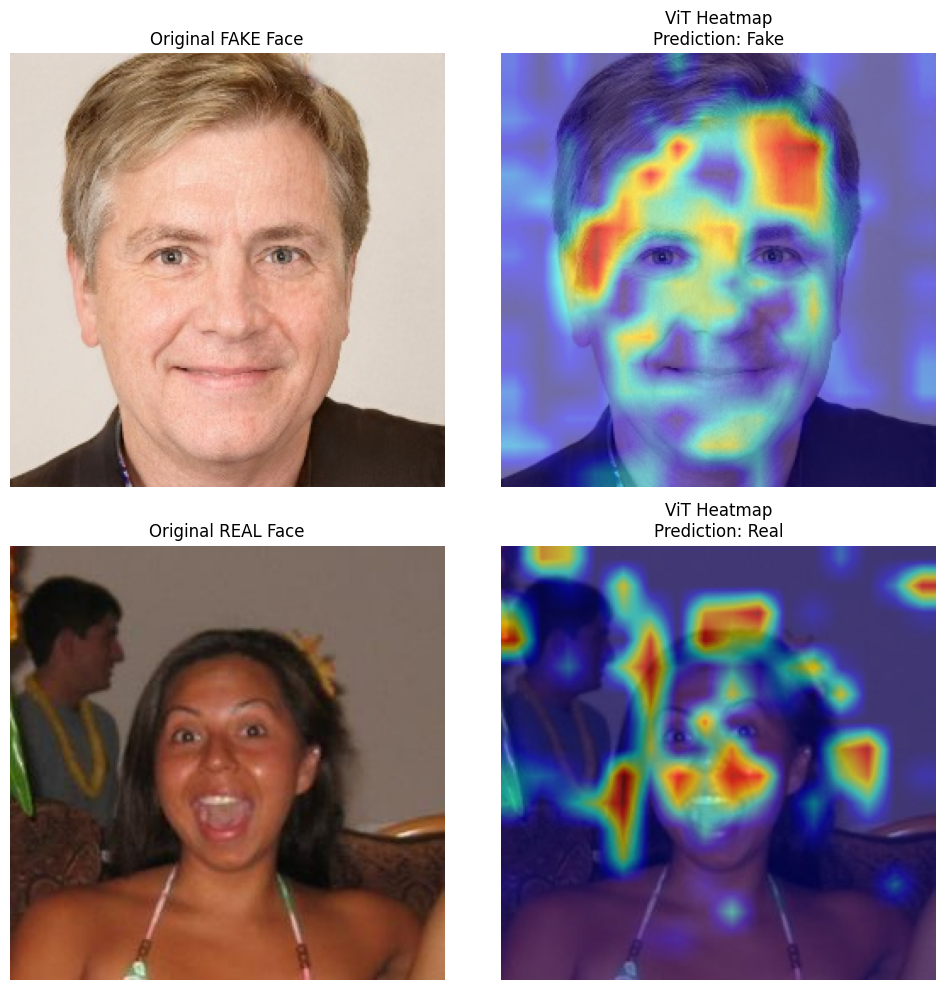

In [83]:
!pip install grad-cam -q

import torchvision.transforms.functional as F_vision
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

# 1. Reshaping function
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 2. Re-normalization function
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# 3. Setup the GradCAM
model_for_cam = model.module if hasattr(model, 'module') else model
target_layers = [model_for_cam.encoder.layers[-1].ln_1]
cam = GradCAM(model=model_for_cam, target_layers=target_layers, reshape_transform=reshape_transform)
model_for_cam.eval()

# 4. Gather all Fake and Real images from the current batch, then pick one randomly!
fake_images, real_images = [], []

# We randomly iterate through a few batches so it isn't always from the first folder
for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i] == 0:
            fake_images.append(images[i])
        elif labels[i] == 1:
            real_images.append(images[i])
    
    # Once we have at least 10 of each to pick from, stop loading batches
    if len(fake_images) > 10 and len(real_images) > 10:
        break

# Randomly select exactly one from our collected lists
img_fake = random.choice(fake_images)
img_real = random.choice(real_images)

# 6. Generate Heatmaps
heatmap_fake = cam(input_tensor=img_fake.unsqueeze(0).to(device))[0, :]
heatmap_real = cam(input_tensor=img_real.unsqueeze(0).to(device))[0, :]

# 7. Format Original Images
orig_fake = np.clip(inv_normalize(img_fake).permute(1, 2, 0).numpy(), 0, 1)
orig_real = np.clip(inv_normalize(img_real).permute(1, 2, 0).numpy(), 0, 1)

# 8. Overlay Heatmaps
vis_fake = show_cam_on_image(orig_fake, heatmap_fake, use_rgb=True)
vis_real = show_cam_on_image(orig_real, heatmap_real, use_rgb=True)

# 9. Plot the grid!
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# FAKE ROW (Top)
axs[0, 0].imshow(orig_fake)
axs[0, 0].set_title("Original FAKE Face")
axs[0, 0].axis('off')

axs[0, 1].imshow(vis_fake)
with torch.no_grad():
    pred_fake = model_for_cam(img_fake.unsqueeze(0).to(device)).argmax(1).item()
axs[0, 1].set_title(f"ViT Heatmap\nPrediction: {'Real' if pred_fake == 1 else 'Fake'}")
axs[0, 1].axis('off')

# REAL ROW (Bottom)
axs[1, 0].imshow(orig_real)
axs[1, 0].set_title("Original REAL Face")
axs[1, 0].axis('off')

axs[1, 1].imshow(vis_real)
with torch.no_grad():
    pred_real = model_for_cam(img_real.unsqueeze(0).to(device)).argmax(1).item()
axs[1, 1].set_title(f"ViT Heatmap\nPrediction: {'Real' if pred_real == 1 else 'Fake'}")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()
